# PHẦN 3 - Áp dụng Canny cho nhiều loại ảnh
Mục tiêu: Đánh giá Canny trên ảnh nhiễu, ảnh tương phản thấp và ảnh nhiều chi tiết.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, exposure
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage.color import rgb2gray
from skimage import io

def add_gaussian_noise(img, var=0.01):
    img_f = img.astype(np.float32) / 255.0 if img.dtype != np.float32 else img
    noisy = random_noise(img_f, mode='gaussian', var=var)
    return img_as_ubyte(noisy)

def to_gray_u8(img):
    if isinstance(img, str):
        img = io.imread(img)
    if img.ndim == 3:
        img = rgb2gray(img)
    if img.dtype != np.uint8:
        img = img_as_ubyte(img)
    return img

def apply_and_show(original, title='', params=None):
    # params: dict for method-specific settings
    gray = to_gray_u8(original)

    # Direct Canny
    edges_direct = cv2.Canny(gray, 100, 200)

    # Pre-blur + Canny
    blurred = cv2.GaussianBlur(gray, (5,5), 1)
    edges_blur = cv2.Canny(blurred, 100, 200)

    # Histogram equalization + Canny (for low contrast)
    heq = cv2.equalizeHist(gray)
    edges_heq = cv2.Canny(heq, 100, 200)

    # Display
    fig, axes = plt.subplots(1, 4, figsize=(18,5))
    
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title(title+' - Original')
    axes[0].axis('off')

    axes[1].imshow(edges_direct, cmap='gray')
    axes[1].set_title('Canny - Direct')
    axes[1].axis('off')

    axes[2].imshow(edges_blur, cmap='gray')
    axes[2].set_title('Gaussian Blur + Canny')
    axes[2].axis('off')

    axes[3].imshow(edges_heq, cmap='gray')
    axes[3].set_title('HistEq + Canny')
    axes[3].axis('off')
    plt.show()

def count_edges(edge_img):
    return int(np.count_nonzero(edge_img))

## Loại ảnh 1 - Ảnh nhiều nhiễu

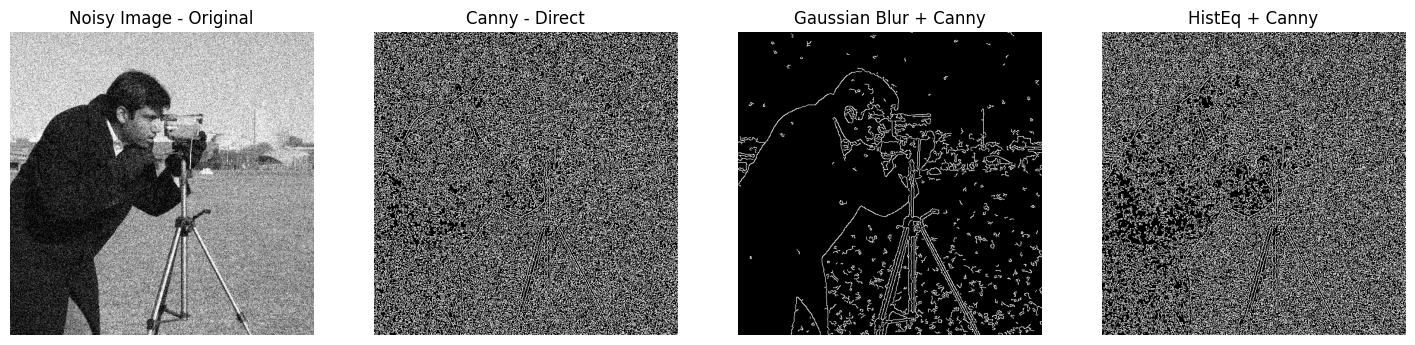

Edges (direct): 93808
Edges (blur+canny): 14043
Edges (hist_eq+canny): 91030


In [6]:
img = data.camera()
noisy = add_gaussian_noise(img, var=0.02)
apply_and_show(noisy, title='Noisy Image')

# Quantitative counts
gray = to_gray_u8(noisy)
print('Edges (direct):', count_edges(cv2.Canny(gray,100,200)))

blurred = cv2.GaussianBlur(gray, (5,5), 1)
print('Edges (blur+canny):', count_edges(cv2.Canny(blurred,100,200)))

heq = cv2.equalizeHist(gray)
print('Edges (hist_eq+canny):', count_edges(cv2.Canny(heq,100,200)))

## Loại ảnh 2 - Ảnh tương phản thấp


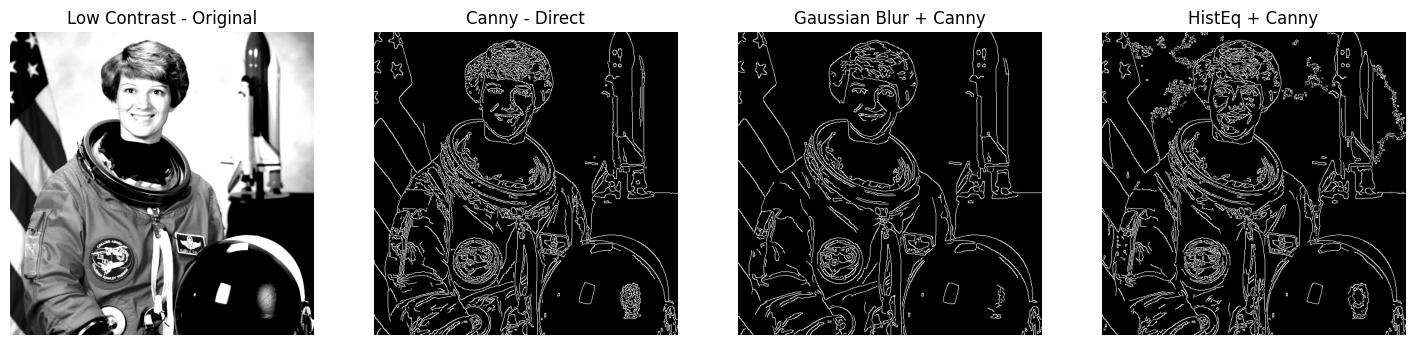

Edges (direct): 24874
Edges (blur+canny): 17974
Edges (hist_eq+canny): 25721


In [ ]:
img = data.astronaut()
# simulate low contrast by rescaling intensity to narrow range
img_low = exposure.rescale_intensity(img, in_range=(50,180))
apply_and_show(img_low, title='Low Contrast')

gray = to_gray_u8(img_low)
print('Edges (direct):', count_edges(cv2.Canny(gray,100,200)))

blurred = cv2.GaussianBlur(gray, (5,5), 1)
print('Edges (blur+canny):', count_edges(cv2.Canny(blurred,100,200)))

heq = cv2.equalizeHist(gray)
print('Edges (hist_eq+canny):', count_edges(cv2.Canny(heq,100,200)))

## Loại ảnh 3 - Ảnh nhiều chi tiết
Áp dụng Canny với nhiều bộ tham số và quan sát mức độ giữ chi tiết / quá nhiều cạnh

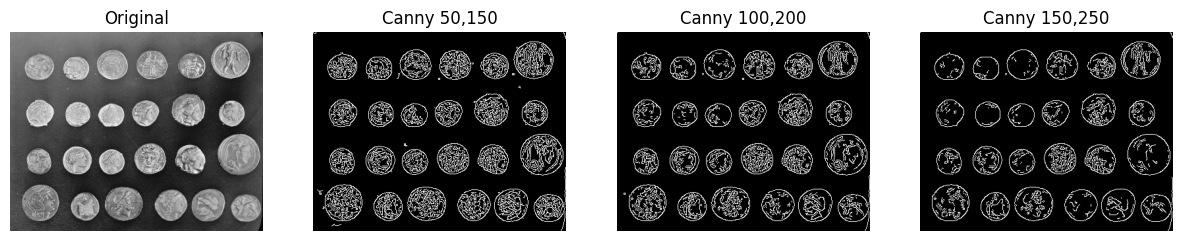

Edges count 50,150: 14955
Edges count 100,200: 12139
Edges count 150,250: 9220


In [4]:
img = data.coins()
gray = to_gray_u8(img)
params = [(50,150),(100,200),(150,250)]
fig, axes = plt.subplots(1, len(params)+1, figsize=(15,5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
for i,(t1,t2) in enumerate(params, start=1):
    e = cv2.Canny(gray, t1, t2)
    axes[i].imshow(e, cmap='gray')
    axes[i].set_title(f'Canny {t1},{t2}')
    axes[i].axis('off')
plt.show()
for t1,t2 in params:
    print(f'Edges count {t1},{t2}:', count_edges(cv2.Canny(gray,t1,t2)))